# Data 612 Project 4

Matthew Tillmawitz

## Introduction

In this project we will be examining how increasing the diversity of recommendations affects different aspects of the quality of recommendations. We will consider different methods of tracking accuracy as well as more business oriented metrics such as catalogue coverage and recommendation novelty. Two models will be developed to provide recommendations, the first using Alternating Least Squares and the second using item based collaborative filtering. Recommendations will consist of a basket of 10 items. We will then use K-means clustering to divide the items into clusters and set a minimum threshold for the number of clusters the items come from in order to generate a more diverse set of recommendations from these models. The recommendations will then be evaluated across a number of metrics to examine how the different recommendations perform.

In [47]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import coo_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
import implicit

## Exploratory Data Analysis

The data used for this project comes from the Netflix prize dataset. A sample of 100,000 ratings was taken that act as a representative sample of the original dataset, with a similar distribution of ratings and degree of sparcity. At 98.27% sparcity, the dataset is typical of data for recommender systems. With 995 users and 5814 movies there are significantly more items than users, which can be unusual and is not typical of streaming services but should not affect performance in a meaningful way. The distribution of ratings skewing left is also typical of real world data.

In [48]:
# Configuration of repeatedly used values, to ensure consistency across the codebase
config = {
    'als_factors': 50,
    'als_regularization': 0.1,
    'als_iterations': 15,
    'itemcf_k': 20,
    'n_clusters': 12,
    'min_cluster_coverage': 0.6,
    'test_size': 0.2,
    'random_state': 8675309
}

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [49]:
df = pd.read_csv('/Users/matttillman/School/data_612/assignments/netflix_subset/netflix_subset_recommender_100000.csv')

Total unique users: 995
Total unique movies: 5814

Rating statistics:
Mean rating: 3.58
Median rating: 4.00
Standard deviation: 1.06
Sparsity: 98.27%


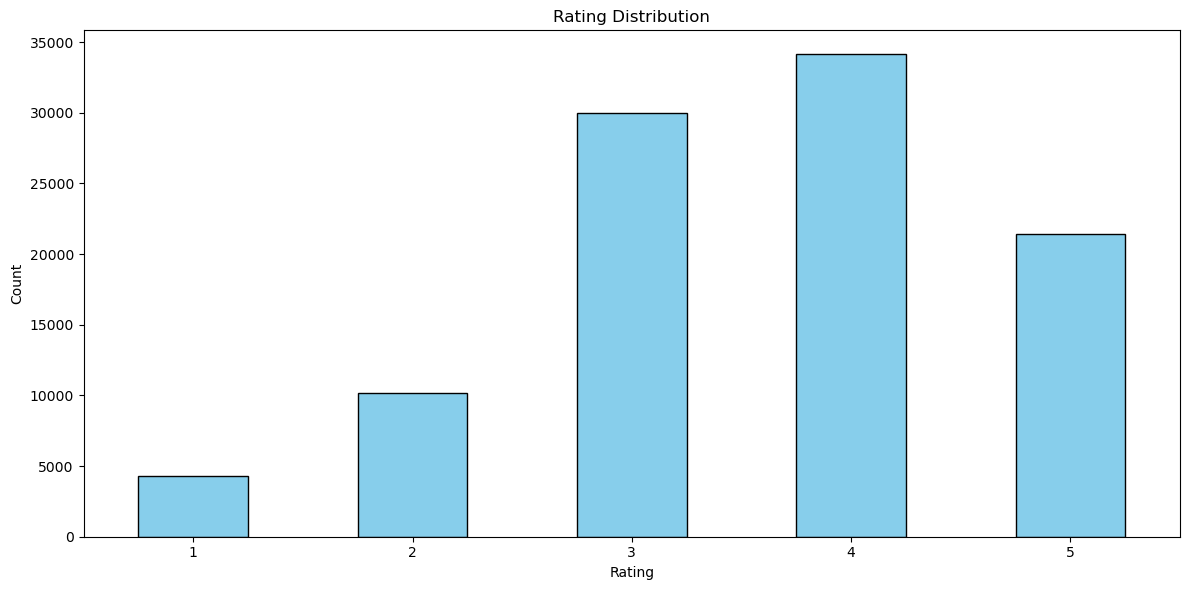

In [50]:
# Basic user statistics
print(f"Total unique users: {df['user_id'].nunique()}")
print(f"Total unique movies: {df['movie_id'].nunique()}")

# Rating statistics
print(f"\nRating statistics:")
print(f"Mean rating: {df['rating'].mean():.2f}")
print(f"Median rating: {df['rating'].median():.2f}")
print(f"Standard deviation: {df['rating'].std():.2f}")
print(f"Sparsity: {(1 - len(df) / (df['user_id'].nunique() * df['movie_id'].nunique())) * 100:.2f}%")

rating_counts = df['rating'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
rating_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

The number of ratings per user follows an exponential decay which is typical, however due to the manner in which this dataset was constructed the average and median number of ratings per user is much higher than normal for recommender systems. The distribution of the ratings themselves is normal and centered on the upper end of the scale which is common for ratings. The number of ratings per movie is much smaller on average and falls off even more rapidly than the number of ratings per user. The distribution of ratings is much more uneven with massive spikes around the natural numbers which is to be expected given the much smaller number of ratings per item. Due to the much sparser nature of the item ratings it was decided to use item based collaborative filtering as a baseline for "simple" models as it is more representative of typical recommendation datasets than the much more densely populated user data. 


Ratings per user statistics:
Mean ratings per user: 100.50
Median ratings per user: 50.00
Min ratings per user: 6
Max ratings per user: 1180

Ratings per movie statistics:
Mean ratings per movie: 17.20
Median ratings per movie: 4.00
Min ratings per movie: 1
Max ratings per movie: 432

User average rating statistics:
Mean of user averages: 3.67
Std of user averages: 0.46

Movie average rating statistics:
Mean of movie averages: 3.38
Std of movie averages: 0.84


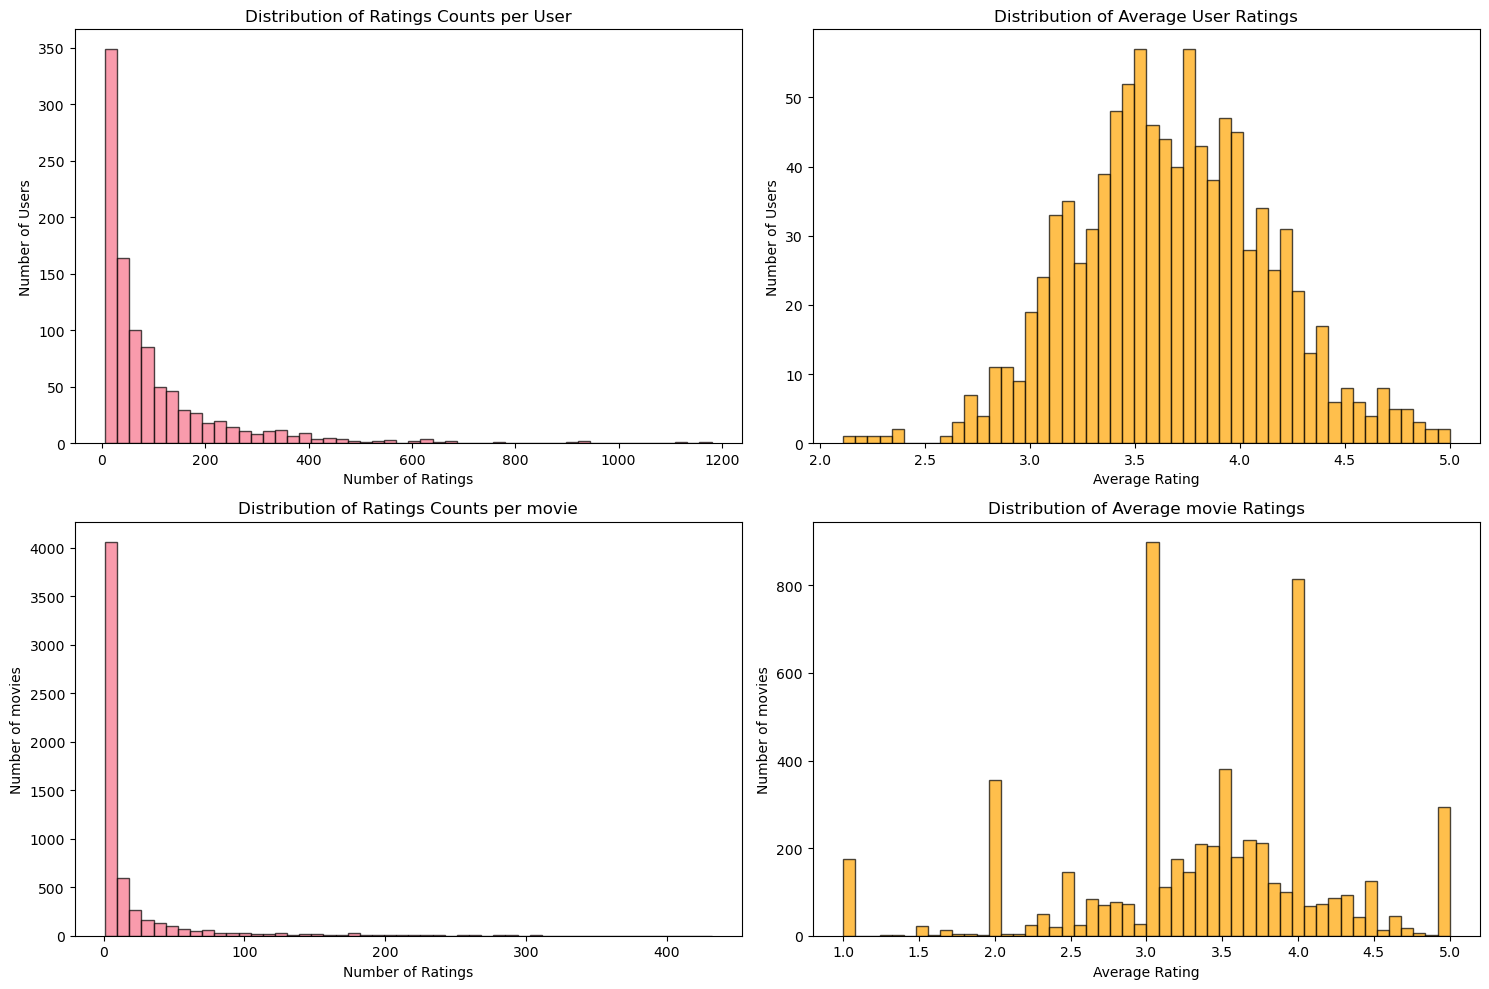

In [51]:
# Ratings per user
user_rating_counts = df['user_id'].value_counts()
print(f"\nRatings per user statistics:")
print(f"Mean ratings per user: {user_rating_counts.mean():.2f}")
print(f"Median ratings per user: {user_rating_counts.median():.2f}")
print(f"Min ratings per user: {user_rating_counts.min()}")
print(f"Max ratings per user: {user_rating_counts.max()}")

# Ratings per movie
movie_rating_counts = df['movie_id'].value_counts()
print(f"\nRatings per movie statistics:")
print(f"Mean ratings per movie: {movie_rating_counts.mean():.2f}")
print(f"Median ratings per movie: {movie_rating_counts.median():.2f}")
print(f"Min ratings per movie: {movie_rating_counts.min()}")
print(f"Max ratings per movie: {movie_rating_counts.max()}")

# User rating behavior
user_avg_ratings = df.groupby('user_id')['rating'].mean()

print(f"\nUser average rating statistics:")
print(f"Mean of user averages: {user_avg_ratings.mean():.2f}")
print(f"Std of user averages: {user_avg_ratings.std():.2f}")

# movie rating behavior
movie_avg_ratings = df.groupby('movie_id')['rating'].mean()

print(f"\nMovie average rating statistics:")
print(f"Mean of movie averages: {movie_avg_ratings.mean():.2f}")
print(f"Std of movie averages: {movie_avg_ratings.std():.2f}")

# User activity distribution
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.hist(user_rating_counts, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Ratings Counts per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')

plt.subplot(2, 2, 2)
plt.hist(user_avg_ratings, bins=50, edgecolor='black', alpha=0.7, color='orange')
plt.title('Distribution of Average User Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Users')

plt.subplot(2, 2, 3)
plt.hist(movie_rating_counts, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Ratings Counts per movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of movies')

plt.subplot(2, 2, 4)
plt.hist(movie_avg_ratings, bins=50, edgecolor='black', alpha=0.7, color='orange')
plt.title('Distribution of Average movie Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of movies')

plt.tight_layout()
plt.show()

## Building the Recommenders

The data is split into a training and test set in an 80/20 split then converted into a sparse matrix data structure to improve modeling performance. Crucially, we convert the dataset from scalar rating values to a simple binary value based on whether the rating was a 4 or 5. This will allow us to optimize for items that we can reasonably expect a user to like instead of accurately predicting whether a poor match would be rated a 1 or a 2. Ultimately what matters is that the user is shown options they would like or find helpful, and converting the ratings to binary values indicating this allows us to better optimize recommendations.

In [52]:
train_df, test_df = train_test_split(
    df, test_size=config['test_size'], random_state=config['random_state'], stratify=df['user_id']
)

unique_users = sorted(df['user_id'].unique())
unique_items = sorted(df['movie_id'].unique())

user_mapping = {user: idx for idx, user in enumerate(unique_users)}
item_mapping = {item: idx for idx, item in enumerate(unique_items)}
# Used later
reverse_user_mapping = {idx: user for user, idx in user_mapping.items()}
reverse_item_mapping = {idx: item for item, idx in item_mapping.items()}

# Convert train triplets to sparse matrix for models, remapping ids since they are a sample of full netflix data and not continuous
train_user_indices = train_df['user_id'].map(user_mapping).values
train_item_indices = train_df['movie_id'].map(item_mapping).values
train_ratings = train_df['rating'].values

user_item_matrix = coo_matrix(
    (train_ratings, (train_user_indices, train_item_indices)),
    shape=(len(user_mapping), len(item_mapping))
).tocsr()

# We only really care if a user liked the movie, doesn't help to accurately predict bad movies
binary_matrix = (user_item_matrix >= 4).astype(float).tocsr()

Training the ALS and IBCF baseline models.

In [53]:
als_model = implicit.als.AlternatingLeastSquares(
    factors=config['als_factors'],
    regularization=config['als_regularization'],
    iterations=config['als_iterations'],
    random_state=config['random_state']
)
als_model.fit(binary_matrix)

100%|██████████| 15/15 [00:00<00:00, 26.16it/s]


In [54]:
itemcf_model = implicit.nearest_neighbours.CosineRecommender(K=config['itemcf_k'])
itemcf_model.fit(binary_matrix)

100%|██████████| 5814/5814 [00:00<00:00, 158264.32it/s]


## Feature Engineering and Clustering

In order to improve the diversity of recommendations, we will be experimenting with clustering the movies based on the data available and requiring recommendations to span a minimum number of the sets. For this project we will construct features based on the distributions of ratings themselves as well as generating latent features using matrix factorization. In a real-world scenario we would likely want to consider many more features based on the metadata for the movies and even analysis of the scripts, but we have limited information and must work with what we have. From the ratings we can track the average rating, standard deviation, log of popularity, and polarization. The log of popularity is more useful than the raw popularity as the range of rating counts is very large and helps prevent undue influence from outliers. Polarization is an interesting metric constructed from the ratio of high and low ratings which can help differentiate recommendations for users with few ratings. For the latent features we are choosing a relatively small number of components at 10 so as to not overwhelm the ratings features and make them irrelevant.

The clustering method chosen was K-means and the number of clusters was fixed at 12 for this project. K-means was chosen to make generating a reasonable number of interpretable clusters with relatively even distributions easier and to make experimentation quicker. As clustering itself is not the focus of this project a fixed value that produced reasonable clusters was chosen instead of a more systematic approach through experimentation. In a real world scenario more sophisticated clustering methods that can handle non-linear boundaries between clusters such as DBSCAN would be more appropriate. The generated clusters exhibit some clear differences that make the goal of increasing recommendation diversity more clear.

In [55]:
# Create item features directly from training data
item_stats = train_df.groupby('movie_id')['rating'].agg([
    'mean', 'std', 'count',
    lambda x: (x >= 4).mean(),  # high_rating_ratio
    lambda x: (x <= 2).mean(),  # low_rating_ratio
]).fillna(0)

item_stats.columns = ['mean_rating', 'rating_std', 'popularity', 'high_rating_ratio', 'low_rating_ratio']

# Add derived features. Log popularity deals with some items being super popular and others having very little data better, polarization can produce more interesting recommendations
item_stats['log_popularity'] = np.log1p(item_stats['popularity'])
item_stats['polarization'] = item_stats['high_rating_ratio'] + item_stats['low_rating_ratio']

# Remove corellated features
features_for_clustering = item_stats[['mean_rating', 'rating_std', 'log_popularity', 'polarization']].copy()

# Create latent features
item_user_matrix = binary_matrix.T.tocsr()

svd = TruncatedSVD(n_components=10, random_state=config['random_state'])
item_latent = svd.fit_transform(item_user_matrix)

# Create latent features DataFrame
latent_df = pd.DataFrame(
    item_latent, 
    index=[reverse_item_mapping[i] for i in range(len(unique_items))],
    columns=[f'latent_{i}' for i in range(10)]
)

clean_features = features_for_clustering.join(latent_df, how='left').fillna(0)

# Perform clustering
scaler = StandardScaler()
features_scaled = scaler.fit_transform(clean_features.values)

kmeans = KMeans(n_clusters=config['n_clusters'], random_state=config['random_state'], n_init=10)
cluster_labels = kmeans.fit_predict(features_scaled)

# Create item-to-cluster mapping
item_clusters = dict(zip(clean_features.index, cluster_labels))

# Print cluster summary
cluster_summary = item_stats.copy()
cluster_summary['cluster'] = [item_clusters.get(item_id, -1) for item_id in item_stats.index]
summary = cluster_summary.groupby('cluster').agg({
    'mean_rating': 'mean',
    'log_popularity': 'mean', 
    'polarization': 'mean',
    'cluster': 'count'
}).round(3)
summary.columns = ['Avg_Rating', 'Avg_Log_Popularity', 'Avg_Polarization', 'Item_Count']

print(f"Created {config['n_clusters']} item clusters:")
print(summary)

Created 12 item clusters:
         Avg_Rating  Avg_Log_Popularity  Avg_Polarization  Item_Count
cluster                                                              
0             3.783               2.822             0.744         272
1             3.264               1.914             0.646        1894
2             4.384               0.900             0.999         953
3             3.496               2.895             0.668         368
4             3.892               5.095             0.775          41
5             2.991               0.867             0.026         670
6             3.440               4.541             0.659         113
7             3.798               2.289             0.800         366
8             3.745               4.829             0.737          50
9             1.613               0.776             0.997         449
10            3.864               4.280             0.778          96
11            3.742               3.670             0.718       

As we can see, there are some obvious differences between clusters based on the ratings metrics with some clusters containing very controversial films and others focusing on consensus. Some contain very popular movies, while others have less popular movies that have very high ratings. It should be evident that forcing recommendations to span these clusters will result in much more diversity in the recommendations users see. While there are some very large and some very small clusters, most have several hundred members meaning we are unlikely to have scenarios where poor recommendations are forced upon users in order to meet diversity thresholds. As mentioned earlier, different clustering methodologies and tuning could better address this possibility but these clusters are adequate for our purposes.

Functions to generate recommendations, both baseline and with increased diversity.

In [56]:
# Get k recommendations for user, k can be set later for cluster spanning sets
def get_recommendations(model, user_id, k=10, filter_seen=True):
    if user_id not in user_mapping:
        return []
    
    user_idx = user_mapping[user_id]
    
    try:
        # Both models now use the same binary matrix format
        user_vector = binary_matrix[user_idx]
        
        # Both models should work with the same API now
        item_indices, scores = model.recommend(
            user_idx, 
            user_vector, 
            N=k*2,
            filter_already_liked_items=filter_seen
        )
        
        # Convert back to original item IDs
        recommendations = []
        for item_idx, score in zip(item_indices, scores):
            if item_idx < len(reverse_item_mapping):  # Check bounds
                original_item_id = reverse_item_mapping[item_idx]
                recommendations.append((original_item_id, score))
        
        return recommendations[:k]
        
    except Exception as e:
        print(f"Error getting recommendations for user {user_id} with {type(model).__name__}: {e}")
        return []

# Ensure recommendations span the required number of clusters
def apply_diversity(recommendations, k=10):
    if not recommendations:
        return []
    
    # Add cluster information
    recs_with_clusters = [
        (item_id, score, item_clusters.get(item_id, -1))
        for item_id, score in recommendations
    ]
    
    # Sort by score
    recs_with_clusters.sort(key=lambda x: x[1], reverse=True)
    
    selected = []
    clusters_used = set()
    
    # Now that things work can simplify this
    min_clusters = max(2, int(k * config['min_cluster_coverage']))
    
    # Make sure we span the minimum clusters, then fill in with best remaining recs
    for item_id, score, cluster in recs_with_clusters:
        if len(clusters_used) < min_clusters and cluster not in clusters_used:
            selected.append(item_id)
            clusters_used.add(cluster)
            if len(selected) >= k:
                break
    
    for item_id, score, cluster in recs_with_clusters:
        if len(selected) >= k:
            break
        if item_id not in selected:
            selected.append(item_id)
    
    return selected[:k]

Due to issues with library compatibility, the metrics are manually implemented in this project. Since the ratings were converted to binary values, metrics like RMSE are not very relevant. For a sparse binary dataset accuracy is also a very poor metric, as we could hypothetically generate a model with >98% by naively labeling every rating a 0. We will therefore be using precision and recall at K as the metrics for quality of recommendations. We are using these metrics at K instead of over the entire dataset as we care more that a given basket of recommendations contains quality recommendations than performance over the whole set. Other metrics we will consider that go beyond accuracy are the total catalog coverage, novelty of a given set of recommendations, and diversity of recommendations. The catalog coverage is simply the proportion of the total catalog that is ever recommended and reflects whether only popular items are being recommended. Novelty is calculated as the negative logarithm of the probability of encountering the item (in the training set) and reflects how likely the model is to recommend items that are not frequently engaged with. Diversity is calculated as the average cosine distance between items in the list of recommendations and reflects how similar the recommended items are to each other.

In [57]:
def precision_at_k(actual_lists, predicted_lists, k=10):
    precisions = []
    for actual, predicted in zip(actual_lists, predicted_lists):
        if len(predicted) == 0:
            precisions.append(0.0)
            continue
        
        predicted_k = predicted[:k]
        actual_set = set(actual)
        relevant_items = len([item for item in predicted_k if item in actual_set])
        precision = relevant_items / len(predicted_k)
        precisions.append(precision)
    
    return np.mean(precisions) if precisions else 0.0

def recall_at_k(actual_lists, predicted_lists, k=10):
    recalls = []
    for actual, predicted in zip(actual_lists, predicted_lists):
        if len(actual) == 0:
            recalls.append(0.0)
            continue
        
        predicted_k = predicted[:k]
        actual_set = set(actual)
        relevant_items = len([item for item in predicted_k if item in actual_set])
        recall = relevant_items / len(actual_set)
        recalls.append(recall)
    
    return np.mean(recalls) if recalls else 0.0

def catalog_coverage(predicted_lists, catalog):
    recommended_items = set()
    for predicted in predicted_lists:
        recommended_items.update(predicted)
    
    return len(recommended_items) / len(catalog) if catalog else 0.0

# Novelty calculation based on negative log of popularity, based on readings
def novelty_score(predicted_lists, item_popularity, total_interactions):
    novelty_scores = []
    
    for predicted in predicted_lists:
        if len(predicted) == 0:
            continue
        
        item_novelties = []
        for item in predicted:
            popularity = item_popularity.get(item, 1)
            novelty = -np.log2(popularity / total_interactions)
            item_novelties.append(novelty)
        
        novelty_scores.append(np.mean(item_novelties))
    
    return np.mean(novelty_scores) if novelty_scores else 0.0

# Diversity is average of intra-list diversity using cosine distances
def diversity_score(predicted_lists, item_features_matrix=None):
    if not predicted_lists or item_features_matrix is None:
        return 0.0
    
    diversity_scores = []
    
    for predicted in predicted_lists:
        if len(predicted) <= 1:
            diversity_scores.append(0.0)
            continue
        
        # Get feature vectors for items in this recommendation list
        item_vectors = []
        valid_items = []
        
        for item in predicted:
            if item in item_features_matrix.index:
                item_vectors.append(item_features_matrix.loc[item].values)
                valid_items.append(item)
        
        if len(item_vectors) <= 1:
            diversity_scores.append(0.0)
            continue
        
        item_vectors = np.array(item_vectors)
        similarity_matrix = cosine_similarity(item_vectors)
        
        # Calculate average cosine distance (1 - cosine similarity)
        # Only consider upper triangle (avoid diagonal and duplicates)
        n_items = len(item_vectors)
        distances = []
        
        for i in range(n_items):
            for j in range(i + 1, n_items):
                cosine_dist = 1 - similarity_matrix[i, j]
                distances.append(cosine_dist)
        
        # Average cosine distance for this list
        avg_distance = np.mean(distances) if distances else 0.0
        diversity_scores.append(avg_distance)
    
    return np.mean(diversity_scores) if diversity_scores else 0.0

# Get the metrics defined above
def evaluate_recommendations(model_name, recommendations_dict, test_interactions, item_popularity, catalog, total_interactions, k=10):
    if not recommendations_dict:
        return {metric: 0 for metric in ['precision@10', 'recall@10', 'coverage', 'diversity', 'novelty']}
    
    # Prepare data for evaluation
    actual_lists = []
    predicted_lists = []
    
    for user_id in recommendations_dict.keys():
        if user_id in test_interactions:
            actual_lists.append(test_interactions[user_id])
            predicted_lists.append(recommendations_dict[user_id][:k])
    
    if not actual_lists:
        return {metric: 0 for metric in ['precision@10', 'recall@10', 'coverage', 'diversity', 'novelty']}
    
    # Calculate metrics
    results = {
        'precision@10': precision_at_k(actual_lists, predicted_lists, k=k),
        'recall@10': recall_at_k(actual_lists, predicted_lists, k=k),
        'coverage': catalog_coverage(predicted_lists, catalog),
        'diversity': diversity_score(predicted_lists, clean_features),
        'novelty': novelty_score(predicted_lists, item_popularity, total_interactions)
    }
    
    return results

## Model Performance

In [58]:
test_interactions = test_df.groupby('user_id')['movie_id'].apply(list).to_dict()
item_popularity = train_df.groupby('movie_id').size().to_dict()
catalog = set(train_df['movie_id'].unique())
total_interactions = len(train_df)

test_users = list(test_df['user_id'].unique())

# Sequential recs work fine for the data size
def generate_recommendations_batch(model, test_users, k=10):
    recommendations = {}
    
    for user_id in test_users:
        recs = get_recommendations(model, user_id, k=k)
        if recs:
            recommendations[user_id] = [item_id for item_id, _ in recs]
    
    return recommendations

def generate_diverse_recommendations_batch(model, test_users, k=10):
    recommendations = {}
    
    for user_id in test_users:
        # Need more recs to ensure we have enough to span minimum number of clusters
        base_recs = get_recommendations(model, user_id, k=k*2)
        if base_recs:
            diverse_items = apply_diversity(base_recs, k=k)
            recommendations[user_id] = diverse_items
    
    return recommendations


Generate recommendations

In [59]:
print("ALS...")
als_recs = generate_recommendations_batch(als_model, test_users, k=10)
print("Done")

print("Item-Item CF...")
itemcf_recs = generate_recommendations_batch(itemcf_model, test_users, k=10)
print("Done")

print("Diverse ALS...")
diverse_als_recs = generate_diverse_recommendations_batch(als_model, test_users, k=10)
print("Done")

print("Diverse Item-Item CF...")
diverse_itemcf_recs = generate_diverse_recommendations_batch(itemcf_model, test_users, k=10)
print("Done")

all_recommendations = {
    'ALS': als_recs,
    'Diverse-ALS': diverse_als_recs,
    'Item-Item CF': itemcf_recs,
    'Diverse-Item-CF': diverse_itemcf_recs
}

ALS...
Done
Item-Item CF...
Done
Diverse ALS...
Done
Diverse Item-Item CF...
Done


To put the metrics, particularly precision and recall values, into context we must first refer back to the EDA and data marshaling for a moment. The ratings were converted into a binary value indicating whether a given user "liked" a movie, meaning they rated it 4 or higher. Considering user ratings have an average of 3.58 and standard deviation of 0.46, we can reasonably conclude that fewer than 20% of rated items are "liked" by a given user. Extrapolating a bit, we know the average user has rated 100 items and the median has rated 50, we can therefore expect that the "average user" likes fewer than 20 items and the "median user" likes fewer than 10. This provides a reference point when considering our performance metrics given a basket size of 10 items and the ratings for each user were divided between the training and test sets.

Beginning with the precision at 10, we can see some interesting differences between the model classes. The precision value remains almost constant between the base and diversity-enhanced models, which indicates that increasing diversity of recomendations has little impact on the proportion of relevant items in the basket. The ALS models perform about 10% better than the respective IBCF models, showing a meaningful performance difference. As all models have a value around 0.1 we can be confident that, on average, at least 1 of the 10 items in a given basket will be "liked" by the user regardless of model. In other words, when evaluating 10 item baskets returned by the models there was at least one item on average we know the user liked from the test set. Considering what we know about the ratings and expected number of liked items, the models show reasonably good performance across the board on precision.

Looking at recall at 10, we see a more pronounced difference in model types. The ALS models have much better performance than the IBCF models, indicating they are much more likely to return relevant items in the basket. Diversity enhancements have a similarly small impact on performance as with precision. To put the values themselves in context, we need to understand that recall is measuring the proportion of all relevant items included in the basket, and is therefore capped by the number of items in the basket. Once again, values of around 0.1 are not bad considering there are 5,814 items, but there is significant room for improvement overall.

The diversity and novelty metrics provide more variance in general and provide some interesting insight into the model recommendations. Coverage shows a massive disparity between model types, with the IBCF models recommending a significantly larger proportion of the total catalog than the ALS models. This indicates the ALS models are generally sticking to more popular items, and the IBCF models are exposing users to many more options. The difference in precision and recall are put into better context in this light, and could be worth the tradeoff if larger catalog exposure is desired. The difference in intra-list diversity between the two model types is significantly smaller than the coverage difference in relative terms, indicating that while the IBCF model recommendations are exposing much more of the catalog the items themselves are all still very similar. This is reinforced when considering novelty, where the values between the two model classes similarly differ by around 10%. Looking at the effects of the diversity enhancements, we can see a meaningful improvement in coverage, diversity, and novelty across both model types. Coverage and diversity both improved meaningfully, as one would expect given the enhancements made. Novelty improved similarly for the IBCF model, however the ALS novelty did not show a significant change. This is an interesting development that breaks with established patterns, although given the much lower coverage of the ALS models could simply indicate the model is more conservative in its recommendations.


In [60]:
results = {}
for model_name, recommendations in all_recommendations.items():
    result = evaluate_recommendations(
        model_name, recommendations, test_interactions, item_popularity, catalog, total_interactions, k=10
    )
    results[model_name] = result

# Create results DataFrame
results_df = pd.DataFrame(results).T
print(results_df.round(4))

                 precision@10  recall@10  coverage  diversity  novelty
ALS                    0.1170     0.1024    0.0759     0.1348   8.9714
Diverse-ALS            0.1107     0.0958    0.0822     0.1416   9.0254
Item-Item CF           0.1033     0.0789    0.1958     0.1451   9.8382
Diverse-Item-CF        0.0996     0.0765    0.2116     0.1637   9.9343


## Conclusions

The results of this project provide an interesting starting point for developing these recommenders further. Based on the results, I would argue the IBCF models perform in a more desirable way than the ALS model, performing significantly better in terms of diversity and novelty than the ALS models while only seeing minor losses in precision. While the IBCF models perform significantly worse in terms of recall, the number of possible items makes achieving high recall extremely difficult and is likely not worth trying to achieve. It would be interesting to see if the trends in this project hold in a real world scenario where more features could be constructed from metadata about the movies. In such a scenario the ALS models could have significantly more latent features, although it is difficult to determine how this could impact results.

If we were to take these models into a hypothetical online evaluation scenario, it would be very interesting to see how click-through rate and engagement corelated with precision. We would expect that, for a given basket, there is at least one item that the user would like based on our precision metrics. Click through rate could indicate how confident the user is in the recommendations, and engagement (measured by minutes or proportion of runtime watched) would be a good proxy for satisfaction in the recommendation if users are hesitant to rate items. These metrics can only be gathered in an online scenario, and would give a much better metric for the quality of recommendations than we can get offline. In terms of an actual online experiment, I would like to run A/B testing with different clustering techniques and tuning parameters to get a better idea of the impact of clustering on the diversity metrics. As more features are added the liklihood of decision boundaries becoming non-linear increases, and we would expect methods other than K-means to do a better job of creating well defined clusters. This does not, however, mean that we would be able to generate "better" recommendations based on these clusters. Before going online I would conduct some tuning to determine if there is a more optimal number of clusters, then deploy the diverse versions of the ALS and IBCF models assuming the patterns we saw in this project hold. The added value of metrics like CTR and engagement will give a better idea of there is a meaningful difference in recommendation quality between the model types. While the online evaluation was occuring I would likely conduct more research on feature engineering and using movie metadata to construct additional features which could be used in another online experiment. As features are added additional experiments could be conducted using different clustering methods, resulting in an iterative process of evaluating features, then clustering, then modeling techniques, and so on which would have the added benefit of creating an established cadence for business planning.